# Train-set anatomy breakdown from a dataset JSON
This notebook loads a dataset JSON (like `dreamsim_ensemble_emb_p128_msk_mri.json`), filters to files from the **VarNet MSK dataset2 train split**, reads each file's ISMRMRD header, maps it to an anatomy category, and plots the distribution.

Notes:
- It reuses the same header parsing + `scan_categories` token matching logic as `analize_results_anatomies.ipynb`.
- Paths in the JSON may be absolute (`/data/...`). If those don't exist on this machine, we fall back to using just the filename inside `TRAIN_DATA_DIR`.

In [20]:
import os, json, h5py, xml.dom.minidom as minidom
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Inputs (edit if needed) ---
DATASET_JSON_PATH = '/home/berk/MRI/data_filtering_for_accelerated_mri/datasets_custom/train/dreamsim_ensemble_emb_p128_msk_mri.json'
TRAIN_DATA_DIR = '../../../../../data/datasets/msk_mri_h5/varnet_msk_dataset2/multicoil_train'

# If you want to restrict ONLY to records whose JSON says split=test, keep this True.
# If your dataset JSON isn't split-aware (or you want to trust folder location instead), set it to False.
REQUIRE_JSON_SPLIT_TRAIN = True

# --- Category mapping (copied from existing analysis notebook) ---
scan_categories = {
    'SPINE': {'includes': ['L-SPINE','LSPINE','L SPINE','C-SPINE','CSPINE','C SPINE','T-SPINE','T SPINE',
                          'AX T2 T-SP','AX T2 T-SP WARP']},
    'PELVIS_PUBALGIA': {'includes': ['PELVIS','ATH PUBALGIA']},
    'HIP': {'includes': ['LT HIP','RT HIP']},
    'SCAPULA_RIBS_FEMUR': {'includes': ['RT SCAPULA','RIBS','LT FEMUR']},
    'LEG_TIBFIB': {'includes': ['LT LEG','RT TIB-FIB']},
    'KNEE': {'includes': ['LT KNEE','RT KNEE']},
    'SHOULDER': {'includes': ['LT SHOULDER','RT SHOULDER']},
    'ANKLE': {'includes': ['LT ANKLE','RT ANKLE']},
    'FOOT': {'includes': ['LT FOOT','RT FOOT']},
    'ELBOW': {'includes': ['LT ELBOW']},
    'WRIST_HAND_THUMB': {'includes': ['LT WRIST','RT WRIST','LT THUMB','RT THUMB','RT HAND','WRIST RT']},
}

def parse_header_study_and_patient(h5_path):
    """Return (tStudyDescription, patientID) from ismrmrd_header; (None, None) if missing."""
    try:
        with h5py.File(h5_path, 'r') as f:
            if 'ismrmrd_header' not in f:
                return None, None
            xml_raw = f['ismrmrd_header'][()]
            if isinstance(xml_raw, (bytes, bytearray, np.void)):
                xml_str = bytes(xml_raw).decode(errors='ignore')
            else:
                xml_str = str(xml_raw)
        dom = minidom.parseString(xml_str)

        def _first_text(parent, tag):
            nodes = parent.getElementsByTagName(tag)
            if nodes and nodes[0].firstChild:
                return nodes[0].firstChild.data.strip()
            return None

        # userParameters may have name/value pairs
        study = None
        ups = dom.getElementsByTagName('userParameterString')
        for node in ups:
            name = _first_text(node, 'name')
            if name == 'tStudyDescription':
                study = _first_text(node, 'value')
                break

        # fallback: try studyInformation/studyDescription (not always present)
        if study is None:
            study = _first_text(dom, 'studyDescription')

        # patientID (typical location: subjectInformation/patientID)
        pid = None
        sub = dom.getElementsByTagName('subjectInformation')
        if sub:
            pid = _first_text(sub[0], 'patientID')

        return study, pid
    except Exception:
        return None, None

def categorize(study_desc):
    if not study_desc:
        return None
    s = str(study_desc).upper()
    for cat, info in scan_categories.items():
        for token in info['includes']:
            if token in s:
                return cat
    return None

def resolve_h5_path(fname, entry_path):
    # Prefer JSON-provided path if it exists; otherwise use TEST_DATA_DIR/fname.
    if entry_path and os.path.exists(entry_path):
        return entry_path
    local = os.path.join(TEST_DATA_DIR, fname)
    if os.path.exists(local):
        return local
    return None

print('Dataset JSON:', DATASET_JSON_PATH)
print('Train data dir:', TRAIN_DATA_DIR)
print('Train dir exists:', os.path.isdir(TRAIN_DATA_DIR))

Dataset JSON: /home/berk/MRI/data_filtering_for_accelerated_mri/datasets_custom/train/dreamsim_ensemble_emb_p128_msk_mri.json
Train data dir: ../../../../../data/datasets/msk_mri_h5/varnet_msk_dataset2/multicoil_train
Train dir exists: True


In [26]:
import os, json, h5py, xml.dom.minidom as minidom
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Inputs (edit if needed) ---
DATASET_JSON_PATH = '/home/berk/MRI/data_filtering_for_accelerated_mri/datasets_custom/train/dreamsim_ensemble_emb_p128_msk_mri.json'
TRAIN_DATA_DIR = '../../../../../data/datasets/msk_mri_h5/varnet_msk_dataset2/multicoil_train'

# If you want to restrict ONLY to records whose JSON says split=test, keep this True.
# If your dataset JSON isn't split-aware (or you want to trust folder location instead), set it to False.
REQUIRE_JSON_SPLIT_TRAIN = True

# --- Category mapping (copied from existing analysis notebook) ---
scan_categories = {
    'SPINE': {'includes': ['L-SPINE','LSPINE','L SPINE','C-SPINE','CSPINE','C SPINE','T-SPINE','T SPINE',
                          'AX T2 T-SP','AX T2 T-SP WARP']},
    'PELVIS_PUBALGIA': {'includes': ['PELVIS','ATH PUBALGIA']},
    'HIP': {'includes': ['LT HIP','RT HIP']},
    'SCAPULA_RIBS_FEMUR': {'includes': ['RT SCAPULA','RIBS','LT FEMUR']},
    'LEG_TIBFIB': {'includes': ['LT LEG','RT TIB-FIB']},
    'KNEE': {'includes': ['LT KNEE','RT KNEE']},
    'SHOULDER': {'includes': ['LT SHOULDER','RT SHOULDER']},
    'ANKLE': {'includes': ['LT ANKLE','RT ANKLE']},
    'FOOT': {'includes': ['LT FOOT','RT FOOT']},
    'ELBOW': {'includes': ['LT ELBOW']},
    'WRIST_HAND_THUMB': {'includes': ['LT WRIST','RT WRIST','LT THUMB','RT THUMB','RT HAND','WRIST RT']},
}

# --- Protocol parsing + grouping (adapted from analize_results_protocols.ipynb) ---
def parse_header_protocol(h5_path):
    """Return tProtocolName from ismrmrd_header; None if missing/unparseable."""
    try:
        with h5py.File(h5_path, 'r') as f:
            if 'ismrmrd_header' not in f:
                return None
            xml_raw = f['ismrmrd_header'][()]
            if isinstance(xml_raw, (bytes, bytearray, np.void)):
                xml_str = bytes(xml_raw).decode(errors='ignore')
            else:
                xml_str = str(xml_raw)
        dom = minidom.parseString(xml_str)

        def _first_text(parent, tag):
            nodes = parent.getElementsByTagName(tag)
            if nodes and nodes[0].firstChild:
                return nodes[0].firstChild.data.strip()
            return None

        ups = dom.getElementsByTagName('userParameterString')
        for node in ups:
            name = _first_text(node, 'name')
            if name == 'tProtocolName':
                return _first_text(node, 'value')
        return None
    except Exception:
        return None

def get_contrast_group(proto):
    """Map raw tProtocolName string to merged contrast group."""
    if proto is None:
        return None
    name = str(proto).upper()

    if 'STIR' in name:
        return 'STIR'

    base = None
    if 'PD' in name:
        base = 'PD'
    elif 'T2' in name:
        base = 'T2'
    elif 'T1' in name:
        base = 'T1'
    else:
        return 'OTHER'

    has_fs = 'FS' in name
    has_dixon = 'DIXON' in name

    if base == 'T1':
        return 'T1_FS' if (has_fs or has_dixon) else 'T1'
    if base == 'T2':
        return 'T2_FS' if (has_fs or has_dixon) else 'T2'
    if base == 'PD':
        return 'PD_FS' if (has_fs or has_dixon) else 'PD'
    return 'OTHER'

def parse_header_study_and_patient(h5_path):
    """Return (tStudyDescription, patientID) from ismrmrd_header; (None, None) if missing."""
    try:
        with h5py.File(h5_path, 'r') as f:
            if 'ismrmrd_header' not in f:
                return None, None
            xml_raw = f['ismrmrd_header'][()]
            if isinstance(xml_raw, (bytes, bytearray, np.void)):
                xml_str = bytes(xml_raw).decode(errors='ignore')
            else:
                xml_str = str(xml_raw)
        dom = minidom.parseString(xml_str)

        def _first_text(parent, tag):
            nodes = parent.getElementsByTagName(tag)
            if nodes and nodes[0].firstChild:
                return nodes[0].firstChild.data.strip()
            return None

        # userParameters may have name/value pairs
        study = None
        ups = dom.getElementsByTagName('userParameterString')
        for node in ups:
            name = _first_text(node, 'name')
            if name == 'tStudyDescription':
                study = _first_text(node, 'value')
                break

        # fallback: try studyInformation/studyDescription (not always present)
        if study is None:
            study = _first_text(dom, 'studyDescription')

        # patientID (typical location: subjectInformation/patientID)
        pid = None
        sub = dom.getElementsByTagName('subjectInformation')
        if sub:
            pid = _first_text(sub[0], 'patientID')

        return study, pid
    except Exception:
        return None, None

def categorize(study_desc):
    if not study_desc:
        return None
    s = str(study_desc).upper()
    for cat, info in scan_categories.items():
        for token in info['includes']:
            if token in s:
                return cat
    return None

def resolve_h5_path(fname, entry_path):
    # Prefer JSON-provided path if it exists; otherwise use TRAIN_DATA_DIR/fname.
    if entry_path and os.path.exists(entry_path):
        return entry_path
    local = os.path.join(TRAIN_DATA_DIR, fname)
    if os.path.exists(local):
        return local
    return None

print('Dataset JSON:', DATASET_JSON_PATH)
print('Train data dir:', TRAIN_DATA_DIR)
print('Train dir exists:', os.path.isdir(TRAIN_DATA_DIR))

Dataset JSON: /home/berk/MRI/data_filtering_for_accelerated_mri/datasets_custom/train/dreamsim_ensemble_emb_p128_msk_mri.json
Train data dir: ../../../../../data/datasets/msk_mri_h5/varnet_msk_dataset2/multicoil_train
Train dir exists: True


In [21]:
with open(DATASET_JSON_PATH, 'r') as f:
    ds = json.load(f)

files_dict = ds.get('files', {}) if isinstance(ds, dict) else {}
print('JSON contains', len(files_dict), 'files entries')

rows = []
missing_h5 = []
unknown_cat = []

for fname, meta in files_dict.items():

    h5_path = resolve_h5_path(fname, meta.get('path'))
    if h5_path is None:
        missing_h5.append(fname)
        continue

    study, pid = parse_header_study_and_patient(h5_path)
    cat = categorize(study)
    if cat is None:
        unknown_cat.append(fname)

    num_slices_in_json = None
    if isinstance(meta.get('slices'), dict):
        num_slices_in_json = len(meta['slices'])

    rows.append({
        'file': fname,
        'h5_path': h5_path,
        'json_split': meta.get('split'),
        'study_description': study,
        'patient_id': pid,
        'anatomy': cat,
        'num_slices_in_json': num_slices_in_json,
    })

df = pd.DataFrame(rows)
print('Selected', len(df), 'train files from JSON')
print('Missing .h5 on disk:', len(missing_h5))
print('Uncategorized (no anatomy match):', len(unknown_cat))
df.head(10)

JSON contains 1325 files entries
Selected 1325 train files from JSON
Missing .h5 on disk: 0
Uncategorized (no anatomy match): 0
Selected 1325 train files from JSON
Missing .h5 on disk: 0
Uncategorized (no anatomy match): 0


,file,h5_path,json_split,study_description,patient_id,anatomy,num_slices_in_json
0,meas_MID00414_FID114458_SAG_STIR.h5,/data/datasets/msk_mri_h5/varnet_msk_dataset2/...,train,LSPINE,18.0.217994609,SPINE,7
1,meas_MID00453_FID127010_SAG_STIR.h5,/data/datasets/msk_mri_h5/varnet_msk_dataset2/...,train,C SPINE,18.0.242129349,SPINE,1
2,meas_MID00213_FID135329_AX_PD_FS.h5,/data/datasets/msk_mri_h5/varnet_msk_dataset2/...,train,RT ANKLE,18.0.261379268,ANKLE,26
3,meas_MID00535_FID115486_COR_T1.h5,/data/datasets/msk_mri_h5/varnet_msk_dataset2/...,train,LT SHOULDER,18.0.220059022,SHOULDER,11
4,meas_MID00380_FID132008_AX_T1_FS.h5,/data/datasets/msk_mri_h5/varnet_msk_dataset2/...,train,RT SHOULDER ARTHRO,18.0.253465935,SHOULDER,1
5,meas_MID00372_FID125893_COR_T2_FS.h5,/data/datasets/msk_mri_h5/varnet_msk_dataset2/...,train,RT SHOULDER,18.0.240047416,SHOULDER,11
6,meas_MID00321_FID130391_COR_T2.h5,/data/datasets/msk_mri_h5/varnet_msk_dataset2/...,train,LSPINE,18.0.249845016,SPINE,2
7,meas_MID00020_FID110988_AX_PD_FS.h5,/data/datasets/msk_mri_h5/varnet_msk_dataset2/...,train,RT KNEE,18.0.211751974,KNEE,5
8,meas_MID00093_FID126650_COR_T2_FS_PROX_DIST.h5,/data/datasets/msk_mri_h5/varnet_msk_dataset2/...,train,LT FOOT,18.0.242129009,FOOT,1
9,meas_MID00247_FID117747_AX_PD_FS.h5,/data/datasets/msk_mri_h5/varnet_msk_dataset2/...,train,LT KNEE,18.0.224711893,KNEE,2


,num_files
anatomy,
SPINE,599
KNEE,233
SHOULDER,192
HIP,99
ANKLE,88
FOOT,42
WRIST_HAND_THUMB,32
PELVIS_PUBALGIA,15
ELBOW,13


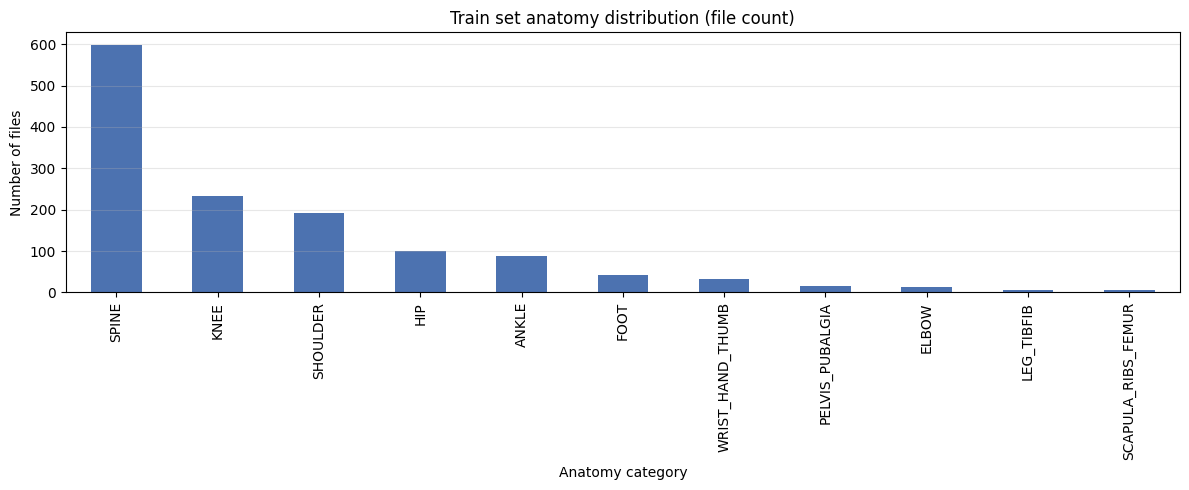

In [22]:
# Show counts per anatomy (by file count)
anatomy_counts = df['anatomy'].fillna('UNKNOWN').value_counts()
display(anatomy_counts.to_frame('num_files'))

plt.figure(figsize=(12, 5))
anatomy_counts.plot(kind='bar', color='#4C72B0')
plt.title('Train set anatomy distribution (file count)')
plt.xlabel('Anatomy category')
plt.ylabel('Number of files')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Total N of slices (sum of num_slices_in_json over selected files): 8293


,num_slices_in_json (sum)
anatomy,
KNEE,2705
SPINE,1922
SHOULDER,1244
ANKLE,1024
HIP,679
WRIST_HAND_THUMB,310
FOOT,274
ELBOW,42
PELVIS_PUBALGIA,42


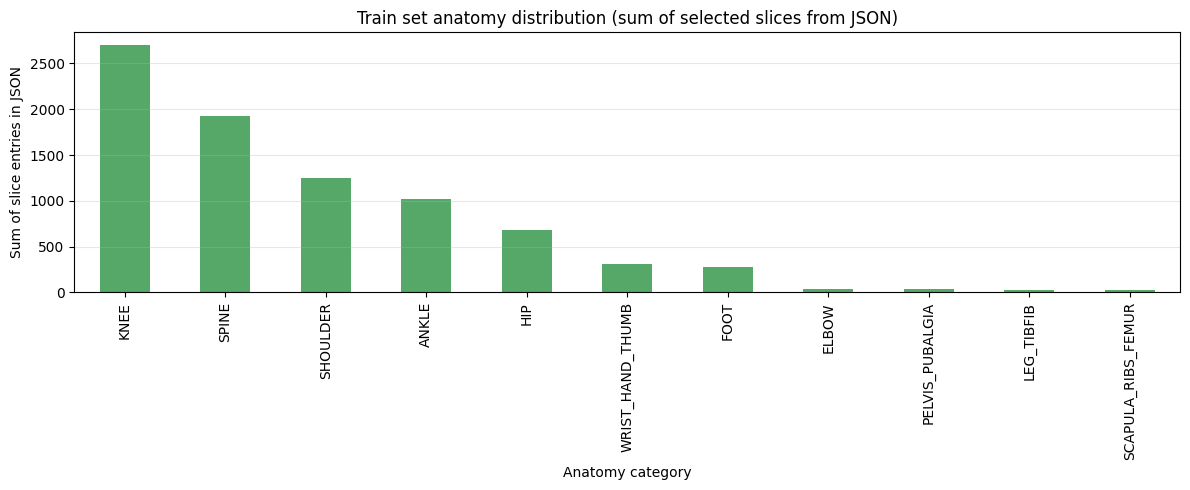

In [23]:
# Optional: counts weighted by number of slices listed in the JSON
if 'num_slices_in_json' in df.columns:
    df_s = df.copy()
    df_s['anatomy'] = df_s['anatomy'].fillna('UNKNOWN')
    # Total number of slice entries represented by the selected files in this JSON
    total_slices = int(df_s['num_slices_in_json'].fillna(0).sum())
    print('Total N of slices (sum of num_slices_in_json over selected files):', total_slices)
    
    slice_counts = (
        df_s.groupby('anatomy')['num_slices_in_json']
        .sum()
        .sort_values(ascending=False)
    )
    display(slice_counts.to_frame('num_slices_in_json (sum)'))
    
    plt.figure(figsize=(12, 5))
    slice_counts.plot(kind='bar', color='#55A868')
    plt.title('Train set anatomy distribution (sum of selected slices from JSON)')
    plt.xlabel('Anatomy category')
    plt.ylabel('Sum of slice entries in JSON')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

Files with protocol_name parsed: 1325 / 1325
Files with protocol_group parsed: 1325 / 1325


,num_files
protocol_group,
T2,405
T1,275
PD_FS,209
T2_FS,202
STIR,138
PD,68
T1_FS,28


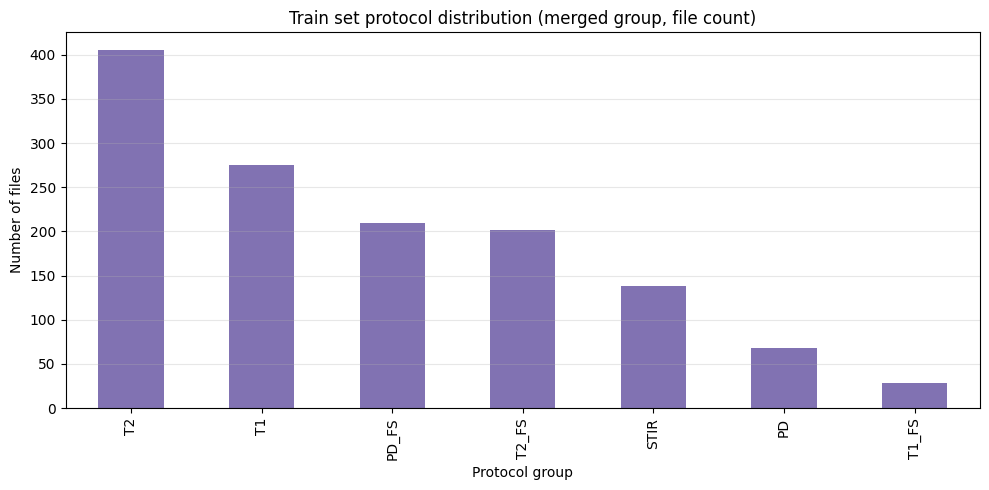

,num_files (top-K)
protocol_name,
COR T2,125
SAG T1,121
SAG STIR,116
SAG T2,115
AX PD FS,104
COR T1,103
SAG T2 FS,80
COR T2 FS,68
SAG PD,65


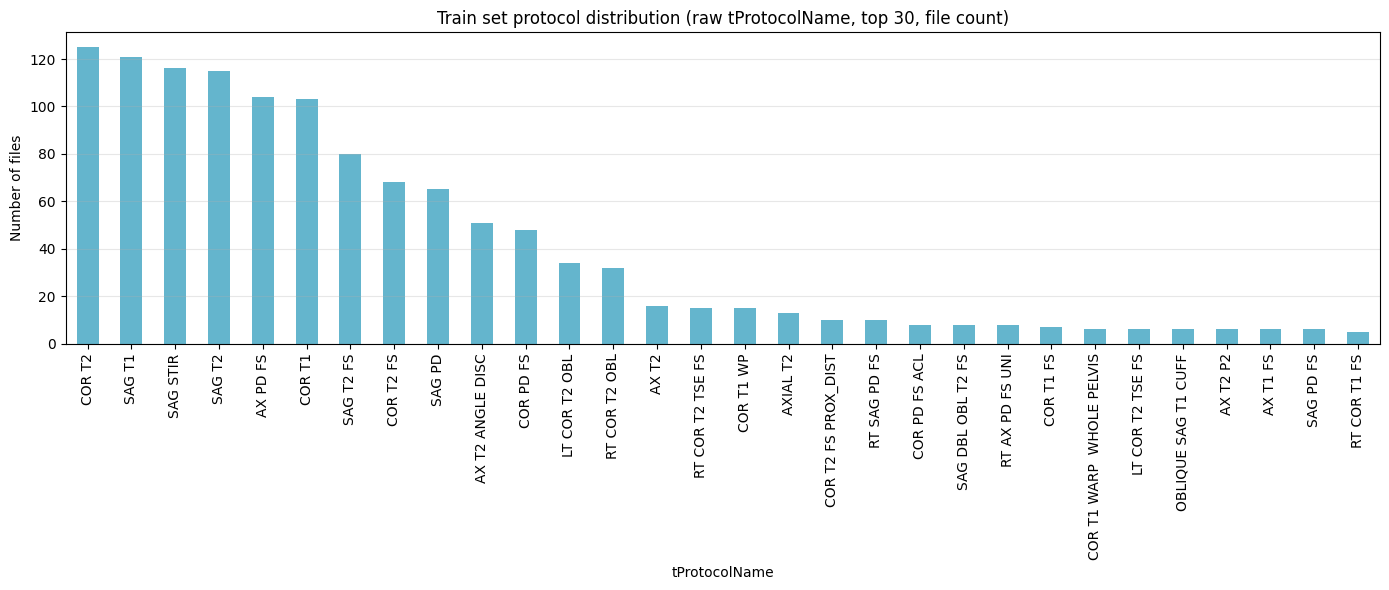

Total N of slices (sum of num_slices_in_json over selected files): 8293


,num_slices_in_json (sum)
protocol_group,
PD_FS,1626
T2_FS,1622
PD,1544
T2,1524
T1,1151
STIR,682
T1_FS,144


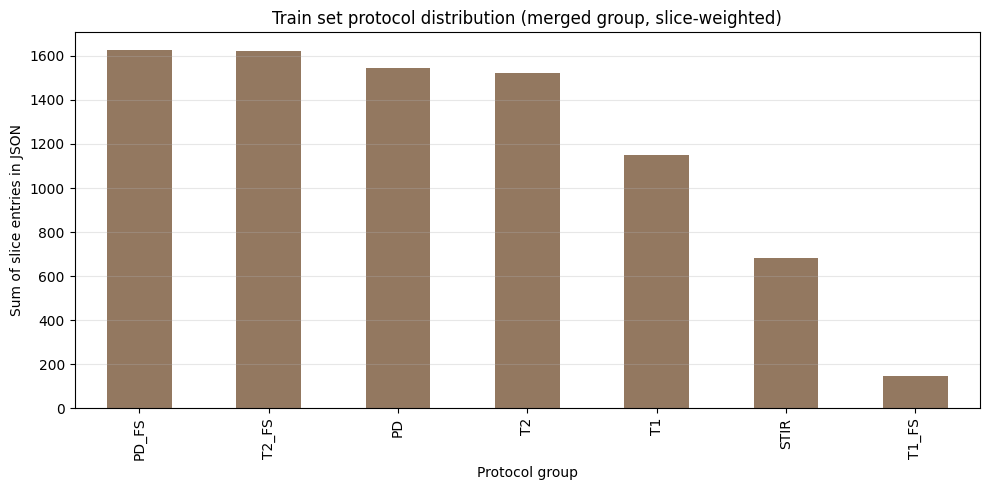

,"num_slices_in_json (sum, top-K)"
protocol_name,
SAG PD,1515
SAG T2 FS,844
AX PD FS,725
COR PD FS,641
COR T1,546
SAG T2,517
COR T2 FS,502
COR T2,502
SAG STIR,493


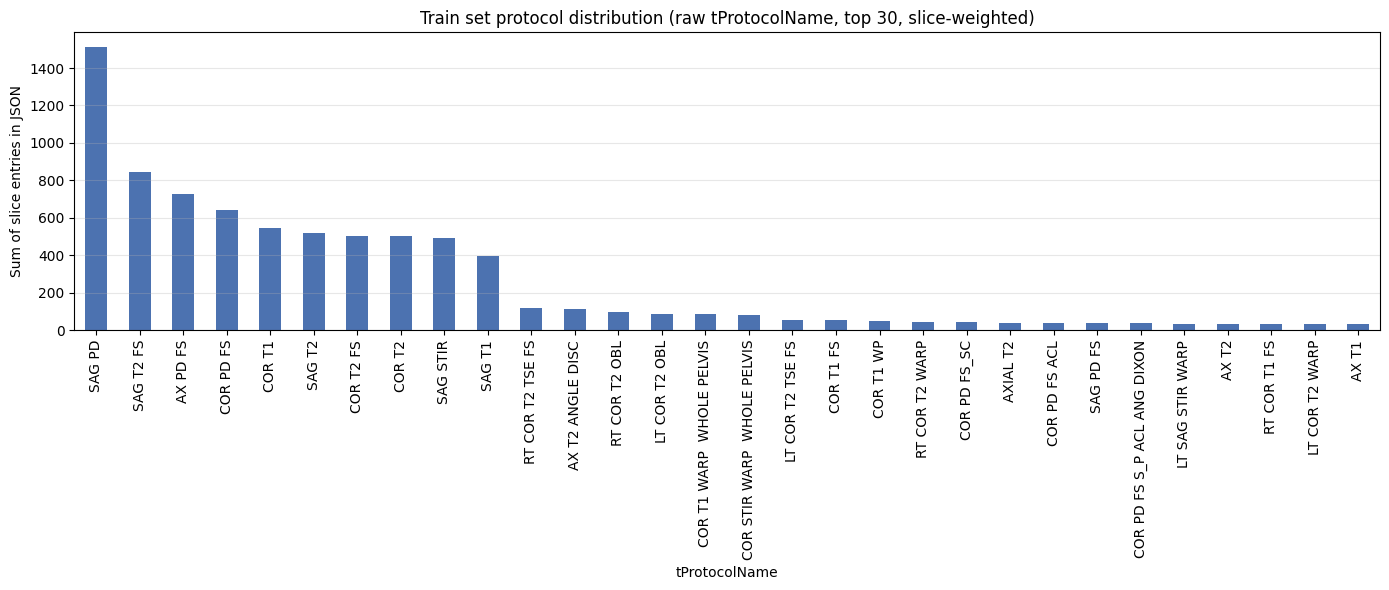

In [27]:
# --- Protocol histograms (from JSON-selected files) ---

# Parse protocol info for each selected file
df_protoinfo = df.copy()
df_protoinfo['protocol_name'] = df_protoinfo['h5_path'].apply(parse_header_protocol)
df_protoinfo['protocol_group'] = df_protoinfo['protocol_name'].apply(get_contrast_group)

print('Files with protocol_name parsed:', int(df_protoinfo['protocol_name'].notna().sum()), '/', len(df_protoinfo))
print('Files with protocol_group parsed:', int(df_protoinfo['protocol_group'].notna().sum()), '/', len(df_protoinfo))

# ----------------- Plot: protocol group histogram (file count) -----------------
proto_group_counts = df_protoinfo['protocol_group'].fillna('UNKNOWN').value_counts()
display(proto_group_counts.to_frame('num_files'))

plt.figure(figsize=(10, 5))
proto_group_counts.plot(kind='bar', color='#8172B2')
plt.title('Train set protocol distribution (merged group, file count)')
plt.xlabel('Protocol group')
plt.ylabel('Number of files')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------- Plot: protocol name histogram (file count, top-K) -----------------
TOPK_PROTOCOLS = 30
proto_name_counts = df_protoinfo['protocol_name'].fillna('UNKNOWN').value_counts()
display(proto_name_counts.head(TOPK_PROTOCOLS).to_frame('num_files (top-K)'))

plt.figure(figsize=(14, 6))
proto_name_counts.head(TOPK_PROTOCOLS).plot(kind='bar', color='#64B5CD')
plt.title(f'Train set protocol distribution (raw tProtocolName, top {TOPK_PROTOCOLS}, file count)')
plt.xlabel('tProtocolName')
plt.ylabel('Number of files')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------- Slice-weighted versions (if num_slices_in_json is available) -----------------
if 'num_slices_in_json' in df_protoinfo.columns:
    dfp = df_protoinfo.copy()
    dfp['num_slices_in_json'] = dfp['num_slices_in_json'].fillna(0).astype(int)

    total_slices = int(dfp['num_slices_in_json'].sum())
    print('Total N of slices (sum of num_slices_in_json over selected files):', total_slices)

    proto_group_slices = (
        dfp.assign(protocol_group=dfp['protocol_group'].fillna('UNKNOWN'))
           .groupby('protocol_group')['num_slices_in_json']
           .sum()
           .sort_values(ascending=False)
    )
    display(proto_group_slices.to_frame('num_slices_in_json (sum)'))

    plt.figure(figsize=(10, 5))
    proto_group_slices.plot(kind='bar', color='#937860')
    plt.title('Train set protocol distribution (merged group, slice-weighted)')
    plt.xlabel('Protocol group')
    plt.ylabel('Sum of slice entries in JSON')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    proto_name_slices = (
        dfp.assign(protocol_name=dfp['protocol_name'].fillna('UNKNOWN'))
           .groupby('protocol_name')['num_slices_in_json']
           .sum()
           .sort_values(ascending=False)
    )
    display(proto_name_slices.head(TOPK_PROTOCOLS).to_frame('num_slices_in_json (sum, top-K)'))

    plt.figure(figsize=(14, 6))
    proto_name_slices.head(TOPK_PROTOCOLS).plot(kind='bar', color='#4C72B0')
    plt.title(f'Train set protocol distribution (raw tProtocolName, top {TOPK_PROTOCOLS}, slice-weighted)')
    plt.xlabel('tProtocolName')
    plt.ylabel('Sum of slice entries in JSON')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

,num_patients
anatomy,
SPINE,134
KNEE,48
SHOULDER,40
HIP,31
ANKLE,18
FOOT,11
WRIST_HAND_THUMB,10
ELBOW,8
PELVIS_PUBALGIA,6


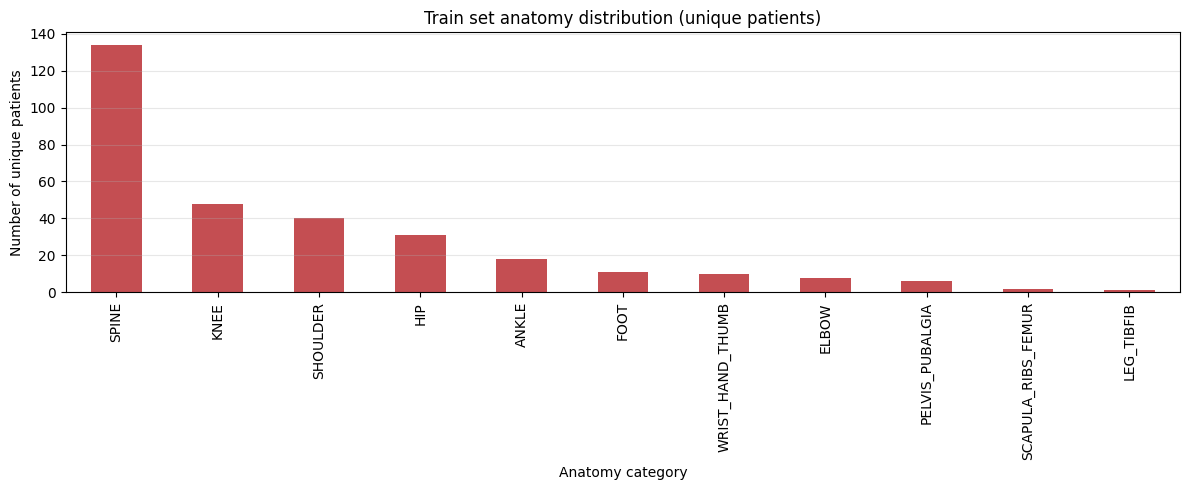

In [24]:
# Optional: patient counts per anatomy (unique patient IDs)
pat = df.dropna(subset=['patient_id']).copy()
if len(pat):
    pat['anatomy'] = pat['anatomy'].fillna('UNKNOWN')
    pat_counts = pat.groupby('anatomy')['patient_id'].nunique().sort_values(ascending=False)
    display(pat_counts.to_frame('num_patients'))

    plt.figure(figsize=(12, 5))
    pat_counts.plot(kind='bar', color='#C44E52')
    plt.title('Train set anatomy distribution (unique patients)')
    plt.xlabel('Anatomy category')
    plt.ylabel('Number of unique patients')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No patient_id available from headers (or all missing).')

In [25]:
# Inspect unknowns / missing files
if missing_h5:
    print('Missing .h5 examples (up to 20):')
    print(missing_h5[:20])

if unknown_cat:
    print('Uncategorized examples (up to 20):')
    print(unknown_cat[:20])

# Quick table of unknown anatomy rows
display(df[df['anatomy'].isna()].head(20))

,file,h5_path,json_split,study_description,patient_id,anatomy,num_slices_in_json
